In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from boruta import BorutaPy
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, Lasso
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr
from tqdm.notebook import tqdm
from sklearn.model_selection import GroupKFold

import warnings
warnings.filterwarnings("ignore")

In [2]:
Xdf = pd.read_csv('msfeature_table2.csv')
Xdf

,pid,year,jerk_5th,jerk_25th,jerk_median,jerk_75th,jerk_95th,jerk_std,dist_5th,dist_25th,...,cf_75th,cf_95th,cf_std,fd_5th,fd_25th,fd_median,fd_75th,fd_95th,fd_std,label
0,C08,2016,472.221508,822.938209,847.671491,863.037190,880.240993,182.106226,0.129896,0.190197,...,4.343523,4.363392,0.078557,0.591176,0.593565,0.594924,0.605422,0.620863,0.012291,1786
1,M49,2022,263.452589,841.913827,863.037190,1817.075446,1961.713106,615.957187,0.094860,0.191574,...,4.306058,4.353424,1.207657,0.558215,0.583758,0.593565,0.603291,0.725373,0.048583,1801
2,C23,2016,288.876422,847.671491,1827.919970,10225.918749,11308.985416,4618.819785,0.137682,0.193101,...,5.706451,5.897226,1.608199,0.329396,0.348327,0.582471,0.594924,0.671767,0.133062,1947
3,C51,2017,363.756762,864.536834,2007.887080,4993.429281,10916.212851,4053.825314,0.171884,0.200366,...,4.697665,5.893762,1.390538,0.329591,0.460871,0.555592,0.593274,0.629206,0.115252,2079
4,M26,2025,570.521123,1280.108332,2297.921237,2890.185797,10709.046674,3668.943138,0.183103,0.271855,...,4.352286,5.890593,1.243055,0.330262,0.518730,0.570591,0.593565,0.639734,0.107202,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,M50,2023,81.113163,1267.936064,2434.483460,4009.456719,7355.330325,2473.040749,0.117447,0.282705,...,4.584712,5.452181,1.238943,0.416664,0.494396,0.541392,0.617063,1.143131,0.249334,2012
160,M07,2016,82.051237,1276.941393,2449.653374,3990.476421,7339.704137,2466.450602,0.117675,0.283128,...,4.594852,5.450300,1.237645,0.414365,0.493751,0.540950,0.615553,1.137972,0.249047,2084
161,M02,2022,82.992973,1276.758083,2433.149027,3981.238729,7321.397752,2461.767644,0.118026,0.283585,...,4.589176,5.448556,1.240734,0.414439,0.493973,0.541392,0.618937,1.132209,0.248334,2269
162,C09,2016,83.087369,1277.817984,2418.783580,3975.957061,7289.446102,2455.173780,0.120060,0.283868,...,4.586042,5.446557,1.236977,0.414568,0.494167,0.541957,0.619553,1.123986,0.247578,2207


In [3]:
# multi_visit_pids = Xdf["pid"].value_counts()[Xdf["pid"].value_counts() > 1].index.tolist()
# multi_visit_pids

In [4]:
Xdf[Xdf["pid"] == 'M14']

,pid,year,jerk_5th,jerk_25th,jerk_median,jerk_75th,jerk_95th,jerk_std,dist_5th,dist_25th,...,cf_75th,cf_95th,cf_std,fd_5th,fd_25th,fd_median,fd_75th,fd_95th,fd_std,label
15,M14,2016,174.613259,874.265562,1818.283864,2537.375704,10113.010217,2515.588551,0.160563,0.272884,...,4.351099,5.743865,1.411291,0.349884,0.514570,0.581871,0.656317,0.849226,0.230240,1868
16,M14,2023,182.058326,897.232940,1846.159051,2568.569217,10074.880242,2445.754466,0.164580,0.272971,...,4.329730,5.741150,1.370245,0.351297,0.515384,0.575106,0.655985,0.847798,0.223741,1842
60,M14,2022,78.454466,1368.154850,2292.475806,3708.119029,7961.895922,2460.605508,0.113404,0.293338,...,4.536039,5.465441,1.366142,0.412570,0.498867,0.548949,0.637323,1.137972,0.243263,1866
124,M14,2020,79.931109,1164.903034,2279.969742,3923.321904,7848.248364,2636.470990,0.116148,0.274499,...,4.583380,5.465159,1.261210,0.410023,0.497079,0.545042,0.627260,1.177158,0.246650,1655
137,M14,2025,75.052307,1192.706036,2278.876447,3936.243031,7615.116153,2584.618514,0.114756,0.275904,...,4.573077,5.466774,1.262776,0.412613,0.497603,0.543399,0.629030,1.181124,0.256427,1860


In [5]:
Xdf_first_visits = Xdf.loc[Xdf.groupby("pid")["year"].idxmin()].reset_index(drop=True)
Xdf_first_visits 

,pid,year,jerk_5th,jerk_25th,jerk_median,jerk_75th,jerk_95th,jerk_std,dist_5th,dist_25th,...,cf_75th,cf_95th,cf_std,fd_5th,fd_25th,fd_median,fd_75th,fd_95th,fd_std,label
0,C01,2016,75.798761,1194.212347,2286.068603,3936.571600,7594.878457,2577.169999,0.114861,0.276007,...,4.579713,5.465994,1.259595,0.412941,0.498278,0.543490,0.628322,1.178195,0.255602,2147
1,C02,2016,169.344734,1034.361541,1966.301534,2823.860409,6017.388164,2230.735474,0.142316,0.279547,...,4.381567,5.678374,1.324801,0.413041,0.507654,0.564753,0.655985,0.918374,0.218792,2216
2,C03,2016,168.708770,1364.769933,2201.662810,3711.604475,10299.234472,2685.245470,0.147342,0.285113,...,4.580339,5.524558,1.237539,0.409003,0.508241,0.552082,0.632643,0.912921,0.207336,2009
3,C04,2016,75.738449,1277.308014,2375.078890,4085.403719,8282.101837,2736.376040,0.110956,0.284066,...,4.634101,5.492537,1.302169,0.406519,0.491545,0.539049,0.618705,1.220142,0.255474,1816
4,C05,2016,78.116784,1237.624727,2427.176872,3939.124208,7378.490100,2480.750903,0.115937,0.281591,...,4.568742,5.456964,1.241328,0.415503,0.495829,0.541665,0.620384,1.169190,0.252090,2323
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,M56,2024,70.555389,1129.549772,2257.521614,3872.203746,7763.029673,2604.552838,0.110956,0.273209,...,4.565070,5.451862,1.278412,0.411612,0.497203,0.545902,0.631310,1.208113,0.260730,1812
116,M57,2024,780.361828,1767.803011,2274.004971,2918.970369,10549.487886,3166.125009,0.190782,0.277016,...,4.431035,5.871236,1.093487,0.333073,0.505440,0.539049,0.587617,0.637416,0.130684,1520
117,M58,2024,156.353749,868.779506,1855.821673,2502.205794,6500.004081,2214.658125,0.138559,0.272713,...,4.309684,5.706407,1.350459,0.407800,0.516916,0.575383,0.675083,0.965797,0.226428,1846
118,M60,2024,81.088568,1292.486247,2260.535191,3556.992688,7702.105598,2415.429319,0.123066,0.285572,...,4.536039,5.440347,1.351516,0.413174,0.494133,0.548949,0.627407,1.122491,0.239011,1458


In [6]:
Xdf_first_visits[Xdf_first_visits['pid'] == 'M14']

,pid,year,jerk_5th,jerk_25th,jerk_median,jerk_75th,jerk_95th,jerk_std,dist_5th,dist_25th,...,cf_75th,cf_95th,cf_std,fd_5th,fd_25th,fd_median,fd_75th,fd_95th,fd_std,label
80,M14,2016,174.613259,874.265562,1818.283864,2537.375704,10113.010217,2515.588551,0.160563,0.272884,...,4.351099,5.743865,1.411291,0.349884,0.51457,0.581871,0.656317,0.849226,0.23024,1868


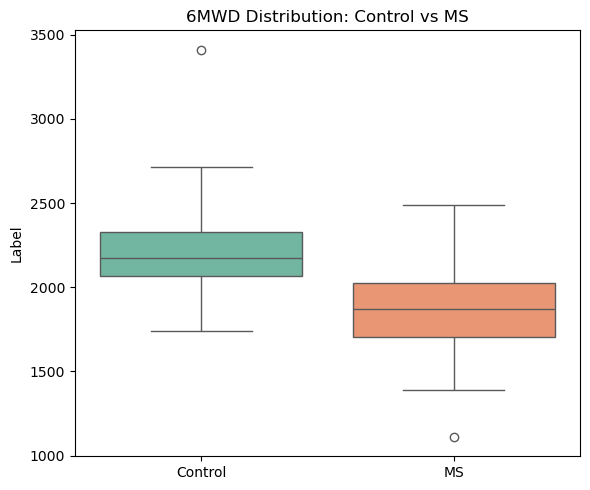

In [7]:
# Add group column
Xdf_first_visits["group"] = Xdf_first_visits["pid"].str[0].map({"C": "Control", "M": "MS"})


# keep Controls with label > 2200, and MS with label < 1870

# if you infer group from pid prefix (e.g., C01 = Control, M56 = MS):
Xdf_first_visits["label"] = pd.to_numeric(Xdf_first_visits["label"], errors="coerce")
is_control = Xdf_first_visits["pid"].astype(str).str.startswith("C")
is_ms = Xdf_first_visits["pid"].astype(str).str.startswith("M")

# mask = (is_control & (Xdf_first_visits["label"] > 2200)) | (is_ms)
# Xdf_first_visits = Xdf_first_visits[mask].reset_index(drop=True)


# Plot side-by-side boxplots for labels
plt.figure(figsize=(6, 5))
sns.boxplot(x="group", y="label", data=Xdf_first_visits, palette="Set2")
plt.title("6MWD Distribution: Control vs MS")
plt.xlabel("")
plt.ylabel("Label")
plt.tight_layout()
plt.show()

In [16]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from boruta import BorutaPy
from tqdm import tqdm

# ---------- Correlation filter (NaN-safe upstream via imputation) ----------
def correlation_filter(X: pd.DataFrame, threshold: float = 0.9):
    Xn = X.select_dtypes(include=[np.number]).copy()
    if Xn.shape[1] <= 1:
        return Xn, []
    corr = Xn.corr().abs().fillna(0.0)
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if (upper[c] > threshold).any()]
    return Xn.drop(columns=to_drop, errors='ignore'), to_drop

# ---------- Group-aware classification pipeline ----------
def run_pipeline_classification(
    Xdf: pd.DataFrame,
    n_splits: int = 9,
    corr_threshold: float = 0.9,
    rf_top_k: int = 10,
    max_nan_frac: float = 0.30
):
    # keep only numeric features (pid, label preserved separately)
    base_X = Xdf.drop(columns=['pid', 'label']).select_dtypes(include=[np.number]).copy()
    Xdf_clean = pd.concat([Xdf[['pid', 'label']].reset_index(drop=True),
                           base_X.reset_index(drop=True)], axis=1)

    X = Xdf_clean.drop(columns=['pid', 'label','year'])
    y = Xdf_clean['label'].values.astype(int)
    groups = Xdf_clean['pid'].values

    models = {
        'KNN': KNeighborsClassifier(),
        'SVM': SVC(probability=True, random_state=42),
        'RandomForest': RandomForestClassifier(n_jobs=-1, random_state=42, class_weight='balanced'),
        'XGBoost': XGBClassifier(n_jobs=-1, random_state=42, eval_metric='logloss'),
        'LogReg': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
        'MLP': MLPClassifier(max_iter=500, random_state=42)
    }

    gkf = GroupKFold(n_splits=n_splits)
    rows = []
    feature_importance_records = []

    for name, model in tqdm(models.items()):
        y_true_all, y_pred_all, y_prob_all = [], [], []

        for tr, te in gkf.split(X, y, groups=groups):
            Xtr_raw, Xte_raw = X.iloc[tr].copy(), X.iloc[te].copy()
            ytr, yte = y[tr], y[te]

            # 0) drop columns with excessive missingness (train-driven)
            nan_frac = Xtr_raw.isna().mean()
            cols_keep = nan_frac[nan_frac <= max_nan_frac].index.tolist()
            if len(cols_keep) == 0:
                cols_keep = Xtr_raw.columns.tolist()
            Xtr_raw = Xtr_raw[cols_keep]
            Xte_raw = Xte_raw[cols_keep]

            # 1) impute NaNs (median)
            imputer = SimpleImputer(strategy='median')
            Xtr_imp = pd.DataFrame(imputer.fit_transform(Xtr_raw), columns=cols_keep, index=Xtr_raw.index)
            Xte_imp = pd.DataFrame(imputer.transform(Xte_raw),     columns=cols_keep, index=Xte_raw.index)

            # 2) remove zero-variance features
            vt = VarianceThreshold(threshold=0.0)
            Xtr_vt = vt.fit_transform(Xtr_imp)
            kept_vt_cols = [c for c, m in zip(cols_keep, vt.get_support()) if m]
            if len(kept_vt_cols) == 0:
                Xtr_vt = Xtr_imp.values
                kept_vt_cols = cols_keep
            Xte_vt = vt.transform(Xte_imp) if hasattr(vt, "get_support") else Xte_imp.values
            Xtr_vt = pd.DataFrame(Xtr_vt, columns=kept_vt_cols, index=Xtr_imp.index)
            Xte_vt = pd.DataFrame(Xte_vt, columns=kept_vt_cols, index=Xte_imp.index)

            # 3) correlation filter
            Xtr_corr, dropped = correlation_filter(Xtr_vt, threshold=corr_threshold)
            if Xtr_corr.shape[1] == 0:
                Xtr_corr = Xtr_vt.copy(); dropped = []
            Xte_corr = Xte_vt.drop(columns=dropped, errors='ignore')
            Xte_corr = Xte_corr[Xtr_corr.columns]

            # 4) Boruta (classifier) with fallbacks
            rf_cls = RandomForestClassifier(n_jobs=-1, random_state=42, class_weight='balanced')
            boruta = BorutaPy(estimator=rf_cls, n_estimators='auto', verbose=0, random_state=42)
            boruta.fit(Xtr_corr.values, ytr)

            mask = boruta.support_ | getattr(boruta, 'support_weak_', np.zeros_like(boruta.support_, dtype=bool))
            selected_cols = Xtr_corr.columns[mask].tolist()

            if len(selected_cols) == 0:
                rf_cls.fit(Xtr_corr, ytr)
                imps = rf_cls.feature_importances_
                order = np.argsort(imps)[::-1]
                k = min(rf_top_k, Xtr_corr.shape[1])
                selected_cols = Xtr_corr.columns[order[:k]].tolist()

            if len(selected_cols) == 0:
                selected_cols = Xtr_corr.columns.tolist()

            Xtr_sel = Xtr_corr[selected_cols]
            Xte_sel = Xte_corr[selected_cols]

            # Record per-fold importances from a fresh RF on the TRAIN fold.
            # We compute on Xtr_corr so importances are comparable across folds (same feature set before selection).
            # rf_imp = RandomForestClassifier(
            #     n_estimators=500, n_jobs=-1, random_state=42, class_weight='balanced'
            # )
            xg_imp = XGBClassifier(n_jobs=-1, random_state=42, eval_metric='logloss')
            xg_imp.fit(Xtr_corr, ytr)
            imp_df = pd.DataFrame({
                "feature": Xtr_corr.columns,
                "importance": xg_imp.feature_importances_
            })
            feature_importance_records.append(imp_df)


            # 5) scale
            scaler = StandardScaler()
            Xtr_scaled = scaler.fit_transform(Xtr_sel)
            Xte_scaled = scaler.transform(Xte_sel)

            # 6) fit & predict
            model.fit(Xtr_scaled, ytr)
            y_pred = model.predict(Xte_scaled)
            # probability or decision function for AUROC
            if hasattr(model, "predict_proba"):
                y_prob = model.predict_proba(Xte_scaled)[:, 1]
            elif hasattr(model, "decision_function"):
                # map decision scores to 0-1 via rank-based scaling if needed
                scores = model.decision_function(Xte_scaled)
                # robust min-max (avoid zero division)
                smin, smax = np.min(scores), np.max(scores)
                y_prob = (scores - smin) / (smax - smin + 1e-12)
            else:
                y_prob = np.full_like(y_pred, fill_value=np.nan, dtype=float)

            y_true_all.extend(yte.tolist())
            y_pred_all.extend(y_pred.tolist())
            y_prob_all.extend(y_prob.tolist())

        y_true_all = np.asarray(y_true_all)
        y_pred_all = np.asarray(y_pred_all)
        y_prob_all = np.asarray(y_prob_all)

        acc  = accuracy_score(y_true_all, y_pred_all)
        bacc = balanced_accuracy_score(y_true_all, y_pred_all)
        f1   = f1_score(y_true_all, y_pred_all, zero_division=0)
        try:
            auroc = roc_auc_score(y_true_all, y_prob_all)
        except Exception:
            auroc = np.nan

        rows.append({
            'Model': name,
            'Accuracy': acc,
            'BalancedAcc': bacc,
            'F1': f1,
            'AUROC': auroc
        })

    if feature_importance_records:
        all_imps = pd.concat(feature_importance_records, axis=0, ignore_index=True)
        mean_imps = (all_imps
                     .groupby("feature", as_index=False)["importance"]
                     .mean()
                     .sort_values("importance", ascending=False))
        print("Top 5 important features across all runs:")
        print(mean_imps.head(10))


    return pd.DataFrame(rows)

In [17]:
dist = Xdf_first_visits["label"]
Xdf_first_visits["label"] = Xdf_first_visits["pid"].str[0].map({"C": 0, "M": 1})
Xdf_bin = Xdf_first_visits.copy()

print(Xdf_bin['label'].value_counts())

# 5) run group-aware classification pipeline
results_cls = run_pipeline_classification(
    Xdf=Xdf_bin,
    n_splits=10,
    corr_threshold=0.9,
    rf_top_k=10,
    max_nan_frac=0.30
)
print(results_cls)

label
0    68
1    52
Name: count, dtype: int64


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [02:53<00:00, 28.95s/it]

Top 5 important features across all runs:
        feature  importance
15      fd_95th    0.076346
31      pwr_5th    0.066705
8      f95_25th    0.054593
21    jerk_95th    0.048649
39      rms_std    0.047227
20    jerk_75th    0.046321
4   dist_median    0.043340
25       mf_5th    0.043149
29       mf_std    0.042501
0     dist_25th    0.041006
          Model  Accuracy  BalancedAcc        F1     AUROC
0           KNN  0.533333     0.522624  0.450980  0.549915
1           SVM  0.566667     0.515837  0.212121  0.447681
2  RandomForest  0.591667     0.576357  0.494845  0.643948
3       XGBoost  0.666667     0.658371  0.607843  0.664310
4        LogReg  0.566667     0.549774  0.458333  0.551471
5           MLP  0.600000     0.588235  0.520000  0.596154


In [18]:
Xdf_bin['dist'] = dist
df = Xdf_bin[['fd_95th','pwr_5th','f95_25th','jerk_95th','rms_std','jerk_75th','dist_median',
              'mf_5th','mf_std','dist_25th','group','dist','label']]
df

,fd_95th,pwr_5th,f95_25th,jerk_95th,rms_std,jerk_75th,dist_median,mf_5th,mf_std,dist_25th,group,dist,label
0,1.178195,16370.957763,7.707036,7594.878457,0.179975,3936.571600,0.353314,1.166827,1.243359,0.276007,Control,0,0
1,0.918374,28454.000942,7.396401,6017.388164,0.128828,2823.860409,0.331954,1.272466,1.300647,0.279547,Control,0,0
2,0.912921,28071.188842,7.645556,10299.234472,0.143950,3711.604475,0.346403,1.270439,1.248889,0.285113,Control,0,0
3,1.220142,14761.925606,7.657048,8282.101837,0.189128,4085.403719,0.355194,1.163918,1.281958,0.284066,Control,0,0
4,1.169190,16469.261010,7.695404,7378.490100,0.173382,3939.124208,0.359374,1.165372,1.228428,0.281591,Control,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,1.208113,16067.582368,7.663360,7763.029673,0.182351,3872.203746,0.350177,1.131828,1.263619,0.273209,MS,1,1
116,0.637416,56494.442922,8.302645,10549.487886,0.151726,2918.970369,0.352738,2.149180,1.062558,0.277016,MS,1,1
117,0.965797,21185.736655,7.273474,6500.004081,0.127503,2502.205794,0.323886,1.228844,1.328658,0.272713,MS,1,1
118,1.122491,15986.160850,7.455533,7702.105598,0.204886,3556.992688,0.352802,1.136845,1.313040,0.285572,MS,1,1


In [21]:
df.shape

(120, 13)

Matplotlib backend: module://matplotlib_inline.backend_inline
Data shape: (120, 10)  Positives: 52  Negatives: 68


,feature,mean_abs_shap
0,pwr_5th,0.118789
1,mf_5th,0.096030
2,rms_std,0.086132
3,jerk_95th,0.084475
4,jerk_75th,0.063280
5,fd_95th,0.062909
6,mf_std,0.062579
7,f95_25th,0.053548
8,dist_median,0.026478
9,dist_25th,0.026057


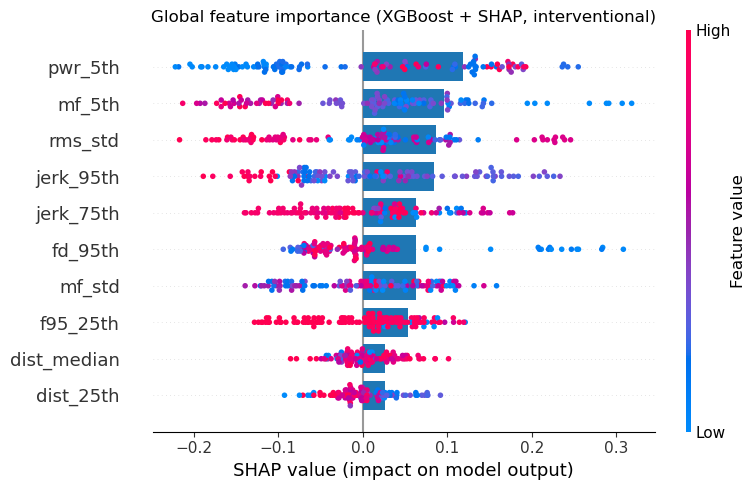

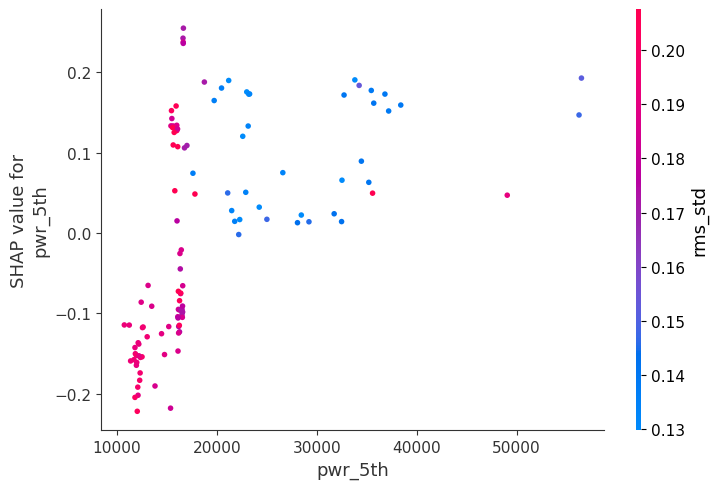

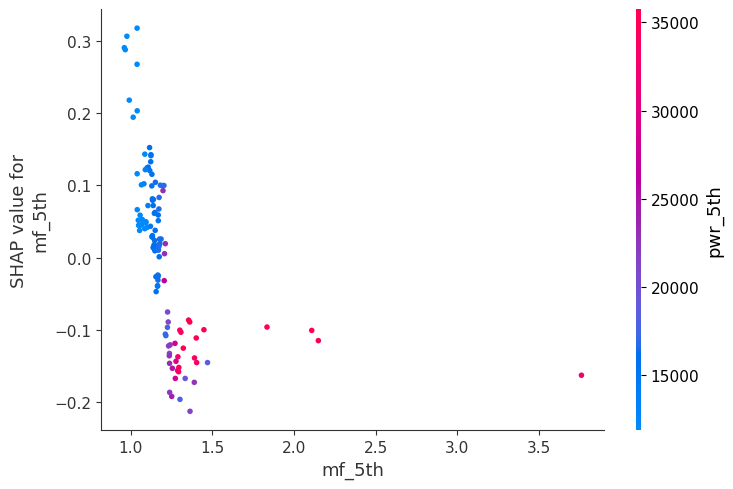

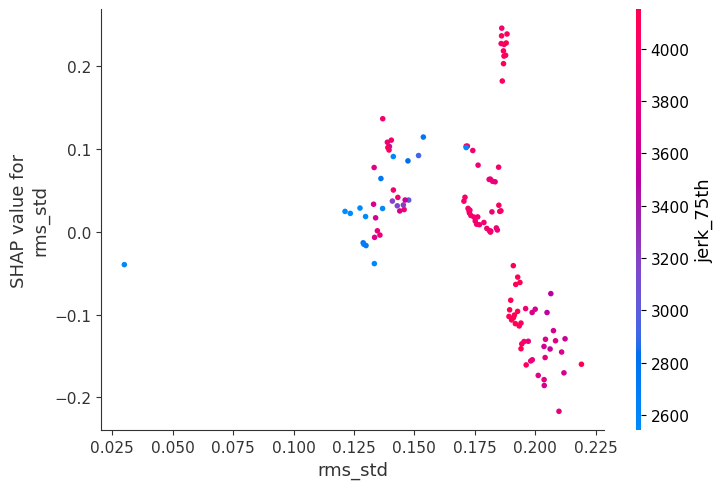

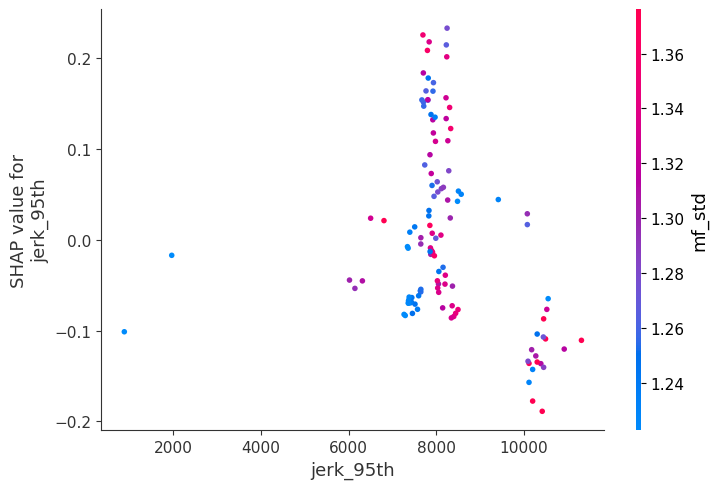

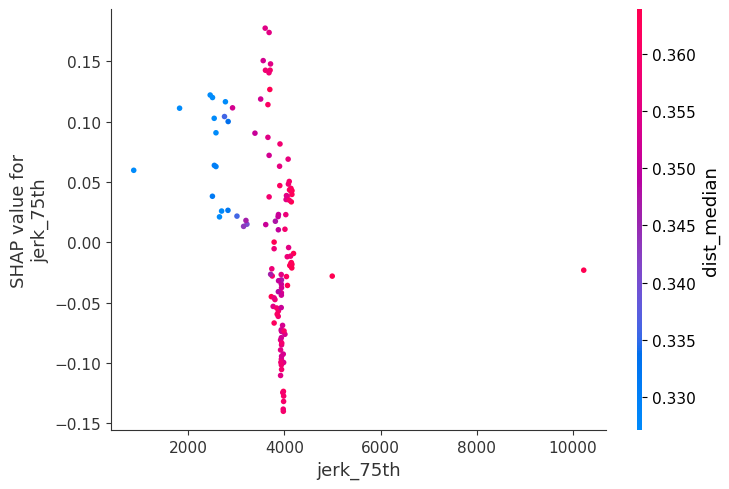

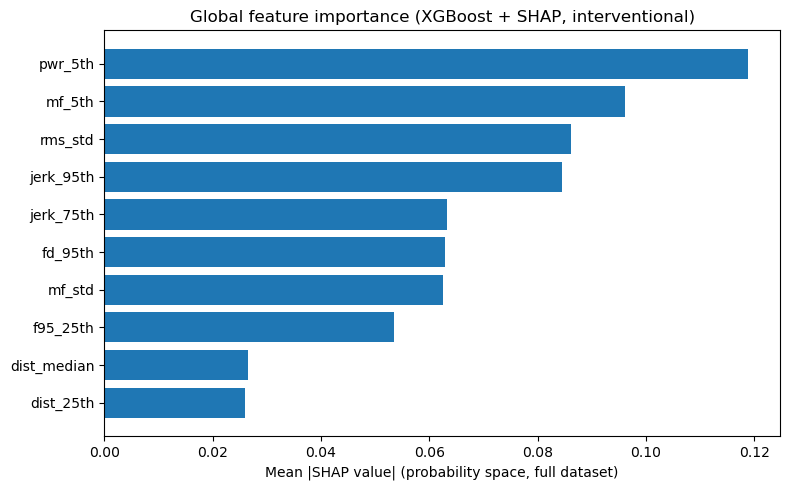

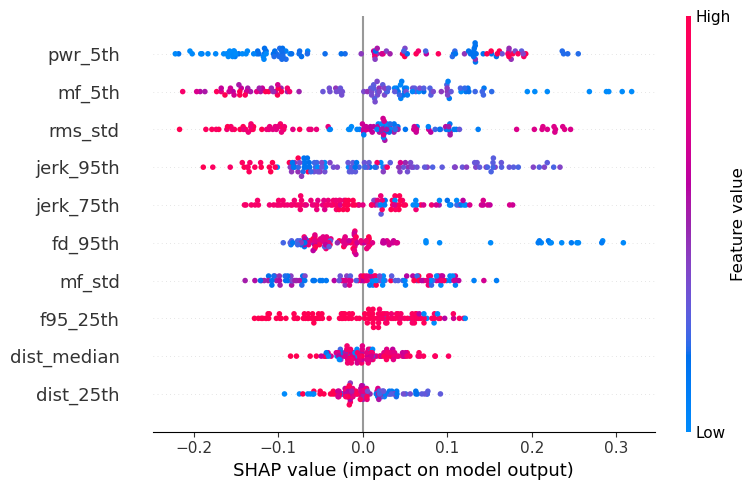

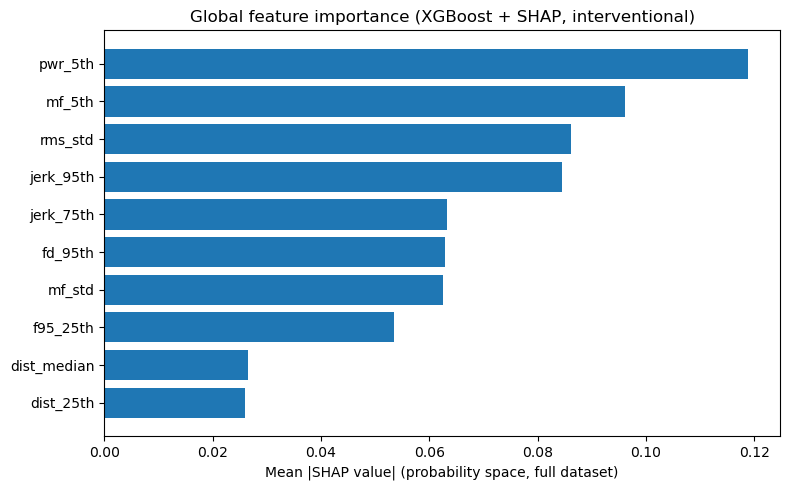

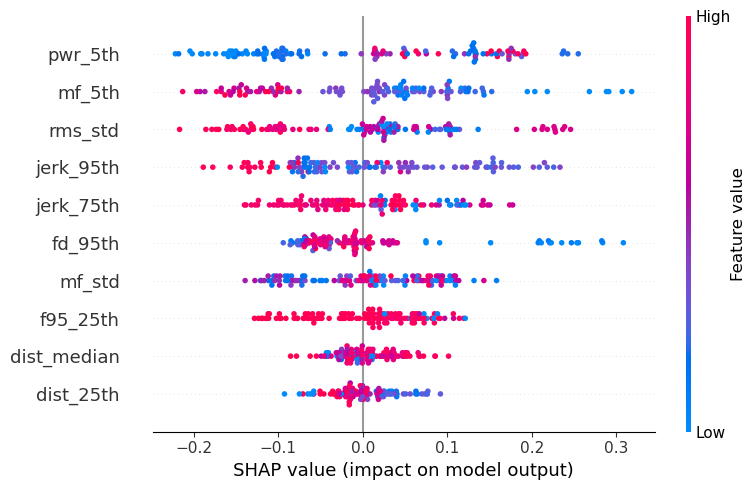

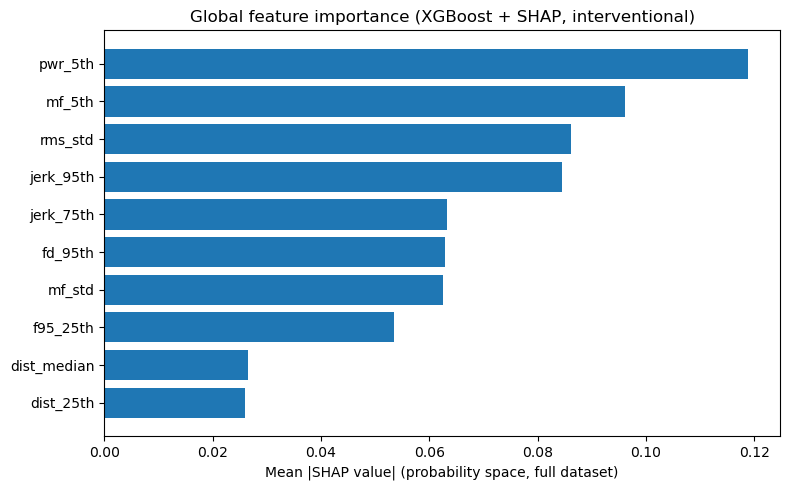

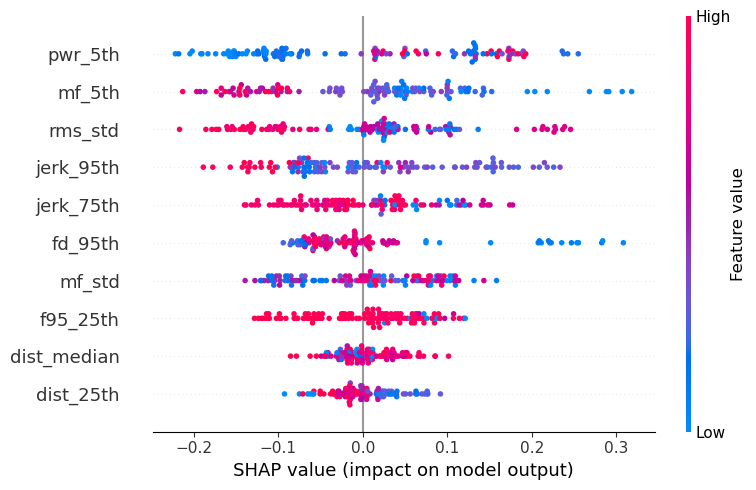

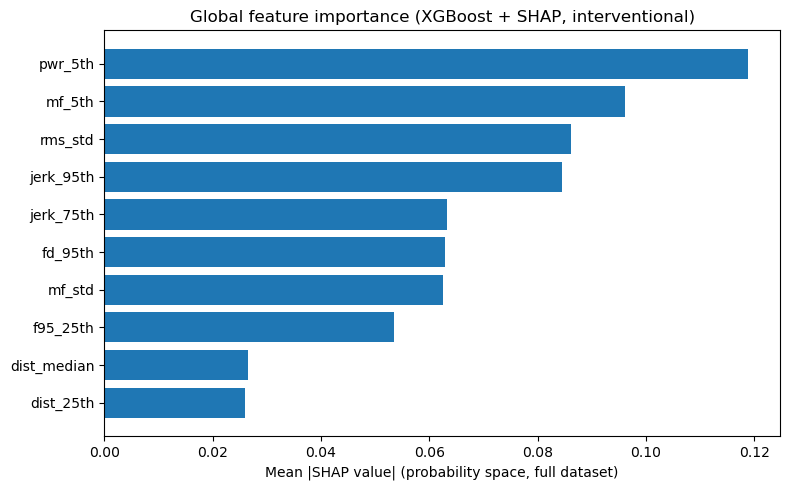

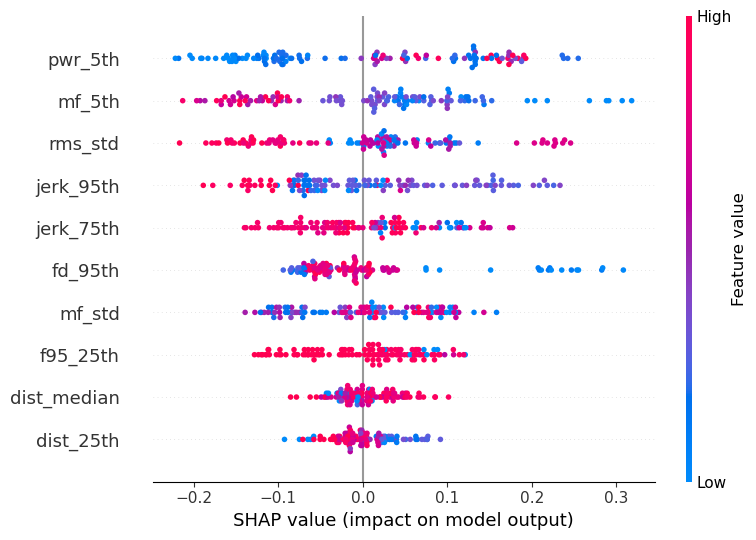

In [26]:
# Jupyter-friendly SHAP on the full dataset (interventional + probability) with inline plots

# 0) notebook display setup — run at the TOP of a notebook cell
%matplotlib inline
import matplotlib
print("Matplotlib backend:", matplotlib.get_backend())  # should be 'module://matplotlib_inline.backend_inline'

# 1) imports
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
import shap
import matplotlib.pyplot as plt

# 2) configuration
FEATURES = [
    'fd_95th','pwr_5th','f95_25th','jerk_95th','rms_std','jerk_75th',
    'dist_median','mf_5th','mf_std','dist_25th'
]
TARGET = 'label'
RANDOM_STATE = 42
TOPK_DEP = 5  # dependence plots to show

# 3) prepare data (expects a DataFrame `df` already defined in the notebook)
df_work = df.copy()
for c in FEATURES:
    df_work[c] = pd.to_numeric(df_work[c], errors='coerce')
df_work[TARGET] = pd.to_numeric(df_work[TARGET], errors='coerce').astype(int)
df_work = df_work.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)

X = df_work[FEATURES].astype('float32')
y = df_work[TARGET].astype('int8')

print("Data shape:", X.shape, " Positives:", int(y.sum()), " Negatives:", int((1 - y).sum()))

# 4) fit XGBoost on FULL data
prior = float(np.clip(y.mean(), 1e-6, 1 - 1e-6))  # safe base_score for logistic loss
model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    n_estimators=800,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    base_score=prior
)
model.fit(X, y, verbose=False)

# 5) SHAP explainer: interventional + probability
bg = X.sample(min(200, len(X)), random_state=RANDOM_STATE)  # background for interventional perturbation
explainer = shap.TreeExplainer(
    model,
    data=bg,
    feature_perturbation="interventional",
    model_output="probability"
)
shap_values = explainer.shap_values(X)  # (n_samples, n_features)

# 6) global importance (mean |SHAP| on FULL X)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = (
    pd.DataFrame({"feature": FEATURES, "mean_abs_shap": mean_abs_shap})
      .sort_values("mean_abs_shap", ascending=False)
      .reset_index(drop=True)
)
display(shap_importance)

# 7) plots (display in notebook)
# 7a) bar chart
plt.figure(figsize=(8, 5))
plt.barh(shap_importance["feature"][::-1], shap_importance["mean_abs_shap"][::-1])
plt.xlabel("Mean |SHAP value| (probability space, full dataset)")
plt.title("Global feature importance (XGBoost + SHAP, interventional)")
plt.tight_layout()
plt.show()

# 7b) SHAP beeswarm summary — let SHAP manage the figure and show it

shap.summary_plot(shap_values, X)  # default show=True for notebooks

# # 7c) optional: dependence plots for top-k features
# topk = shap_importance["feature"].tolist()[:TOPK_DEP]
# for f in topk:
#     shap.dependence_plot(f, shap_values, X, show=True)  # shows immediately in notebook


In [11]:
import numpy as np
import pandas as pd
from scipy import stats

# --- effect sizes ---

def hedges_g(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    mx, my = np.mean(x), np.mean(y)
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)
    sp2 = ((nx-1)*vx + (ny-1)*vy) / (nx+ny-2) if (nx+ny-2) > 0 else np.nan
    if not np.isfinite(sp2) or sp2 <= 0:
        return np.nan
    d = (mx - my) / np.sqrt(sp2)
    # small-sample bias correction
    J = 1 - (3 / (4*(nx+ny) - 9)) if (nx+ny) > 2 else 1.0
    return J * d

def cliffs_delta(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    nx, ny = len(x), len(y)
    if nx == 0 or ny == 0:
        return np.nan
    # Efficient computation using broadcasting with memory guard
    # Fall back to rank-based method for large arrays
    if nx*ny <= 2_000_000:
        comp = np.subtract.outer(x, y)
        delta = (np.sum(comp > 0) - np.sum(comp < 0)) / (nx*ny)
        return float(delta)
    # Rank-based approximation (equivalent)
    ranks = stats.rankdata(np.concatenate([x, y]))
    rx = ranks[:nx].sum()
    U = rx - nx*(nx+1)/2
    delta = (2*U)/(nx*ny) - 1
    return float(delta)

# --- multiple testing (Benjamini–Hochberg FDR) ---

def fdr_bh(pvals):
    p = np.asarray(pvals, float)
    n = p.size
    order = np.argsort(p)
    ranks = np.arange(1, n+1)
    adj = np.empty(n, float)
    adj[order] = np.minimum.accumulate((p[order][::-1] * n / ranks[::-1]))[::-1]
    adj = np.clip(adj, 0, 1)
    return adj

# --- main analysis ---

def analyze_group_differences(df, group_col="group", groups=("Control", "MS"), features=None, alpha=0.05):
    if features is None:
        # all numeric columns except the group column
        features = [c for c in df.columns if c != group_col and pd.api.types.is_numeric_dtype(df[c])]

    g1, g2 = groups
    rows = []
    for feat in features:
        s1 = df.loc[df[group_col] == g1, feat].dropna().astype(float)
        s2 = df.loc[df[group_col] == g2, feat].dropna().astype(float)

        n1, n2 = len(s1), len(s2)
        if n1 < 2 or n2 < 2:
            rows.append({
                "feature": feat, "n_Control": n1, "n_MS": n2,
                "normality_p_Control": np.nan, "normality_p_MS": np.nan,
                "levene_p": np.nan, "test": "insufficient data",
                "statistic": np.nan, "p_value": np.nan,
                "effect_size": np.nan, "effect_name": np.nan,
                "mean_Control": s1.mean() if n1 else np.nan,
                "mean_MS": s2.mean() if n2 else np.nan,
                "std_Control": s1.std(ddof=1) if n1 > 1 else np.nan,
                "std_MS": s2.std(ddof=1) if n2 > 1 else np.nan
            })
            continue

        # normality (Shapiro–Wilk; robust for n up to 5k+)
        try:
            sw1 = stats.shapiro(s1).pvalue if n1 <= 5000 else stats.normaltest(s1).pvalue
            sw2 = stats.shapiro(s2).pvalue if n2 <= 5000 else stats.normaltest(s2).pvalue
        except Exception:
            # fallback: D'Agostino for safety
            sw1 = stats.normaltest(s1).pvalue
            sw2 = stats.normaltest(s2).pvalue

        # variance equality (Levene, center=median helps with mild non-normality)
        lev_p = stats.levene(s1, s2, center='median').pvalue

        approx_normal = (sw1 > alpha) and (sw2 > alpha)

        if approx_normal:
            # Welch’s t-test by default (safer when variances differ)
            t = stats.ttest_ind(s1, s2, equal_var=False)
            stat, p = t.statistic, t.pvalue
            es = hedges_g(s1, s2)
            test_name = "Welch t"
            es_name = "Hedges g"
        else:
            # Nonparametric
            u = stats.mannwhitneyu(s1, s2, alternative='two-sided', method='asymptotic')
            stat, p = u.statistic, u.pvalue
            es = cliffs_delta(s1, s2)
            test_name = "Mann–Whitney U"
            es_name = "Cliff's delta"

        rows.append({
            "feature": feat,
            "n_Control": n1, "n_MS": n2,
            "normality_p_Control": sw1, "normality_p_MS": sw2,
            "levene_p": lev_p,
            "test": test_name,
            "statistic": stat, "p_value": p,
            "effect_size": es, "effect_name": es_name,
            "mean_Control": s1.mean(), "mean_MS": s2.mean(),
            "std_Control": s1.std(ddof=1), "std_MS": s2.std(ddof=1),
            "median_Control": np.median(s1), "median_MS": np.median(s2)
        })

    res = pd.DataFrame(rows)
    res["p_fdr"] = fdr_bh(res["p_value"].fillna(1.0).values)
    res = res.sort_values("p_fdr", ascending=True).reset_index(drop=True)
    return res

# --- run on your DataFrame `df` (with a column named 'group' containing 'Control'/'MS') ---

results = analyze_group_differences(df, group_col="group", groups=("Control", "MS"))
results

,feature,n_Control,n_MS,normality_p_Control,normality_p_MS,levene_p,test,statistic,p_value,effect_size,effect_name,mean_Control,mean_MS,std_Control,std_MS,median_Control,median_MS,p_fdr
0,dist,68,52,1.248188e-04,9.654895e-01,0.462034,Mann–Whitney U,2910.5,1.466371e-09,0.646210,Cliff's delta,2200.014706,1869.923077,266.013887,274.355991,2174.500000,1870.000000,8.798226e-09
1,fd_95th,68,52,1.793921e-06,1.986404e-04,0.397888,Mann–Whitney U,1832.5,7.346551e-01,0.036482,Cliff's delta,1.106654,1.090708,0.160562,0.174252,1.176514,1.156601,7.688153e-01
2,f95_25th,68,52,2.497584e-15,8.100587e-12,0.276055,Mann–Whitney U,1965.0,2.980006e-01,0.111425,Cliff's delta,7.432137,7.249909,0.733354,0.967617,7.587844,7.556874,7.688153e-01
3,pwr_5th,68,52,1.748444e-08,3.946279e-08,0.213601,Mann–Whitney U,1712.0,7.688153e-01,-0.031674,Cliff's delta,18733.827240,20788.132983,7415.679932,10501.845509,16375.829931,16194.152627,7.688153e-01
4,jerk_95th,68,52,1.583610e-08,4.553309e-08,0.528351,Mann–Whitney U,1644.0,5.130802e-01,-0.070136,Cliff's delta,8163.112817,8181.096115,1460.002716,1309.427623,7928.927504,7974.262219,7.688153e-01
5,rms_std,68,52,5.443799e-07,3.016594e-04,0.687885,Mann–Whitney U,1867.0,6.019150e-01,0.055995,Cliff's delta,0.173863,0.171762,0.030008,0.027531,0.181537,0.182878,7.688153e-01


In [15]:
Xdf_bin

,pid,year,jerk_5th,jerk_25th,jerk_median,jerk_75th,jerk_95th,jerk_std,dist_5th,dist_25th,...,cf_std,fd_5th,fd_25th,fd_median,fd_75th,fd_95th,fd_std,label,group,dist
0,C01,2016,75.798761,1194.212347,2286.068603,3936.571600,7594.878457,2577.169999,0.114861,0.276007,...,1.259595,0.412941,0.498278,0.543490,0.628322,1.178195,0.255602,0,Control,2147
1,C02,2016,169.344734,1034.361541,1966.301534,2823.860409,6017.388164,2230.735474,0.142316,0.279547,...,1.324801,0.413041,0.507654,0.564753,0.655985,0.918374,0.218792,0,Control,2216
2,C03,2016,168.708770,1364.769933,2201.662810,3711.604475,10299.234472,2685.245470,0.147342,0.285113,...,1.237539,0.409003,0.508241,0.552082,0.632643,0.912921,0.207336,0,Control,2009
3,C04,2016,75.738449,1277.308014,2375.078890,4085.403719,8282.101837,2736.376040,0.110956,0.284066,...,1.302169,0.406519,0.491545,0.539049,0.618705,1.220142,0.255474,0,Control,1816
4,C05,2016,78.116784,1237.624727,2427.176872,3939.124208,7378.490100,2480.750903,0.115937,0.281591,...,1.241328,0.415503,0.495829,0.541665,0.620384,1.169190,0.252090,0,Control,2323
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,M56,2024,70.555389,1129.549772,2257.521614,3872.203746,7763.029673,2604.552838,0.110956,0.273209,...,1.278412,0.411612,0.497203,0.545902,0.631310,1.208113,0.260730,1,MS,1812
116,M57,2024,780.361828,1767.803011,2274.004971,2918.970369,10549.487886,3166.125009,0.190782,0.277016,...,1.093487,0.333073,0.505440,0.539049,0.587617,0.637416,0.130684,1,MS,1520
117,M58,2024,156.353749,868.779506,1855.821673,2502.205794,6500.004081,2214.658125,0.138559,0.272713,...,1.350459,0.407800,0.516916,0.575383,0.675083,0.965797,0.226428,1,MS,1846
118,M60,2024,81.088568,1292.486247,2260.535191,3556.992688,7702.105598,2415.429319,0.123066,0.285572,...,1.351516,0.413174,0.494133,0.548949,0.627407,1.122491,0.239011,1,MS,1458
